# Carga de datos

Esta sección carga el dataset de Pokémon y muestra una vista inicial de las columnas y registros.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "data/pokemon_complete_2025.csv"

# Cargar los datos con pandas para trabajar de forma consistente y evitar flujos duplicados.
df = pd.read_csv(DATA_PATH, on_bad_lines="skip")

print("Columnas disponibles:", df.columns.tolist())
print(df.head(3))

Columnas disponibles: ['pokedex_id', 'name', 'genus', 'generation', 'type_1', 'type_2', 'num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m', 'weight_kg', 'base_experience', 'ability_1', 'ability_2', 'hidden_ability', 'color', 'shape', 'habitat', 'growth_rate', 'egg_groups', 'is_legendary', 'is_mythical', 'is_baby', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'description', 'sprite_url', 'is_dual_type', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'gender_distribution', 'stat_tier']
   pokedex_id       name         genus generation type_1  type_2  num_types  \
0           1  bulbasaur  Seed Pokémon          I  grass  poison          2   
1           2    ivysaur  Seed Pokémon          I  grass  poison          2   
2           3   venusaur  Seed Pokémon          I  grass  poison          2   

   hp  attack  defense  ...  \
0  45      49       49  ...   

# Limpieza y Preprocesamiento

Convertimos la columna de generaciones en valores numéricos y centralizamos la lógica de conversión.

In [3]:
import numpy as np
import pandas as pd

# --- DETECCIÓN AUTOMÁTICA DE COLUMNAS ---
# Limpiamos los nombres de las columnas por si tienen espacios locos
df.columns = df.columns.str.strip().str.lower()

# Buscamos la columna que represente el segundo tipo
posibles_nombres_tipo2 = ["type2", "type 2", "type_2", "tipo2", "tipo 2"]
col_tipo2 = next((c for c in df.columns if c in posibles_nombres_tipo2), None)

# 1. Mapa de conversión de generaciones
generation_map = {
    "I": 1, "II": 2, "III": 3, "IV": 4,
    "V": 5, "VI": 6, "VII": 7, "VIII": 8, "IX": 9
}

if "generation" in df.columns:
    df["generation_number"] = (
        df["generation"].astype(str).str.strip().map(generation_map)
        .fillna(0)
        .astype(int)
    )

# 2. Identificar columnas de stats
posibles_stats = {
    "hp", "attack", "defense", "special-attack", "special-defense", 
    "special_attack", "special_defense", "speed", "sp_attack", "sp_defense", "sp_atk", "sp_def"
}
stat_columns = [col for col in df.columns if col in posibles_stats]

def ensure_total_stats(dataframe):
    for col in stat_columns:
        dataframe[col] = pd.to_numeric(dataframe[col], errors='coerce').fillna(0)
    dataframe["total_stats"] = dataframe[stat_columns].sum(axis=1)
    return dataframe

df = ensure_total_stats(df)

# 3. Crear columna para tipo dual (USANDO LA COLUMNA DETECTADA)
if col_tipo2:
    df["es_dual"] = df[col_tipo2].notna() & (df[col_tipo2].astype(str).str.lower() != "nan")
else:
    print("ADVERTENCIA: No se encontró la columna de Tipo 2. Asumiendo todos falsos.")
    df["es_dual"] = False

# Verificamos qué nombres quedaron
print("Nombres de columnas actuales:", df.columns.tolist())
print(df[["generation_number", "total_stats", "es_dual"]].head(8))

Nombres de columnas actuales: ['pokedex_id', 'name', 'genus', 'generation', 'type_1', 'type_2', 'num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m', 'weight_kg', 'base_experience', 'ability_1', 'ability_2', 'hidden_ability', 'color', 'shape', 'habitat', 'growth_rate', 'egg_groups', 'is_legendary', 'is_mythical', 'is_baby', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'description', 'sprite_url', 'is_dual_type', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'gender_distribution', 'stat_tier', 'generation_number', 'total_stats', 'es_dual']
   generation_number  total_stats  es_dual
0                  1          318     True
1                  1          405     True
2                  1          525     True
3                  1          309    False
4                  1          405    False
5                  1          534     True
6                  1  

# Análisis Estadístico

Calculamos la distribución de Pokémon por generación en el dataset y validamos la coherencia de total_stats.

In [4]:
# Estadísticas de frecuencia de generación.
generation_counts = (
    df["generation_number"]
    .value_counts(sort=False)
    .sort_index()
)

values = generation_counts.index.to_numpy()
counts = generation_counts.to_numpy()

# Estadísticas de distribución de total_stats.
total_stats_mean = df["total_stats"].mean()
total_stats_std = df["total_stats"].std()

print("Generaciones:", values)
print("Conteos:", counts)
print(f"Total stats - media: {total_stats_mean:.2f}, desviación estándar: {total_stats_std:.2f}")

# Cálculo de proporciones Único vs Dual.
type_proportions = df["es_dual"].value_counts(normalize=True) * 100
percent_unique = type_proportions.get(False, 0.0)
percent_dual = type_proportions.get(True, 0.0)
print(f"Único: {percent_unique:.1f}%")
print(f"Dual: {percent_dual:.1f}%")
print(f"Suma porcentajes: {(percent_unique + percent_dual):.1f}%")

Generaciones: [1 2 3 4 5 6 7 8 9]
Conteos: [151 100 135 107 156  72  88  96 120]
Total stats - media: 427.69, desviación estándar: 112.77
Único: 48.7%
Dual: 51.3%
Suma porcentajes: 100.0%


# Visualización

Generamos el plot de barras verticales por generación, el histograma de poder total, el gráfico de barras apiladas por tipo, el promedio de poder por generación y el heatmap de combinaciones de tipos.

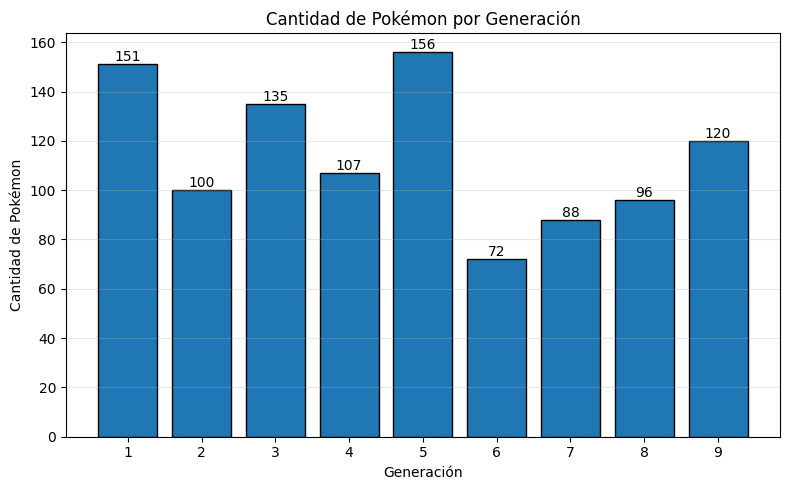

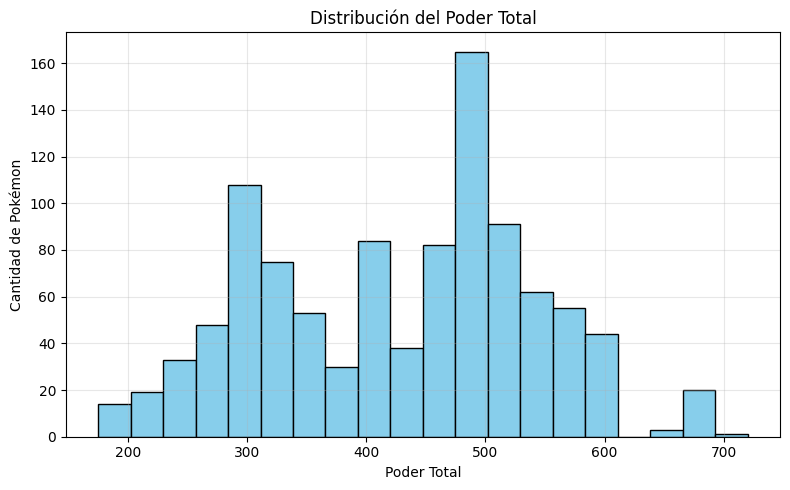

<Figure size 800x600 with 0 Axes>

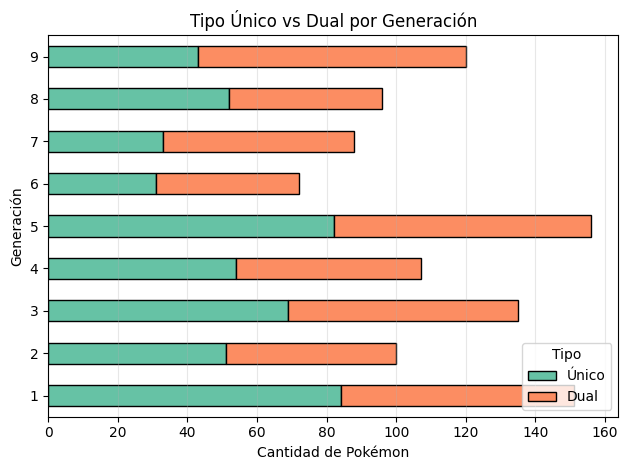

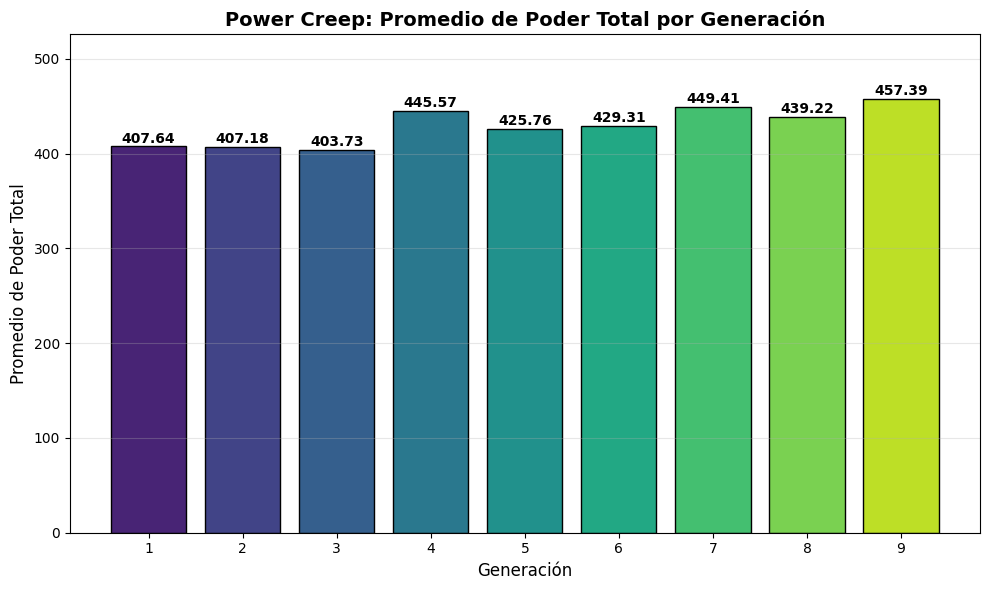

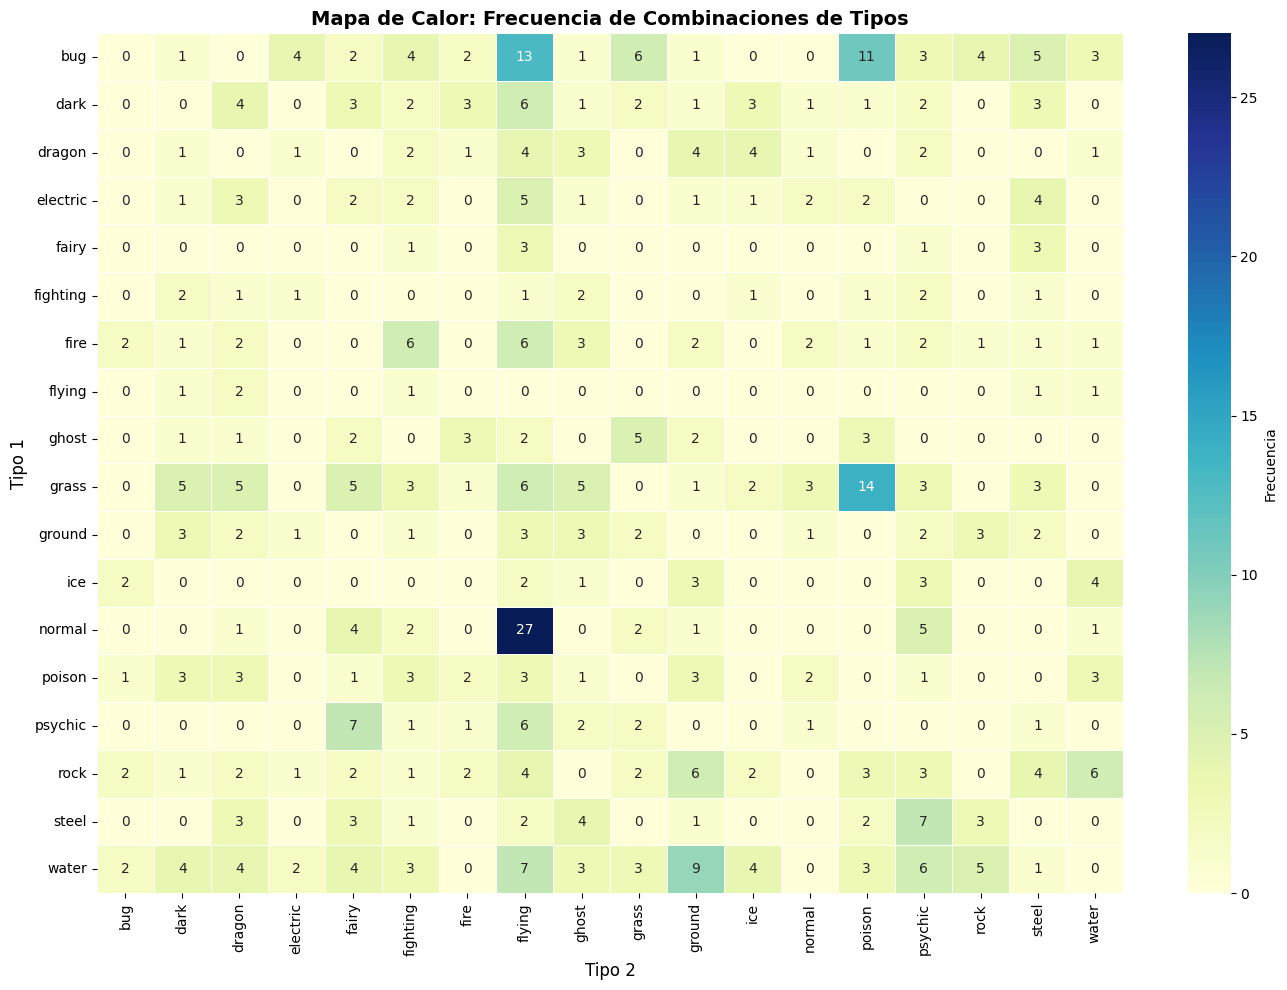

In [5]:
# =================================================================
# SECCIÓN: VISUALIZACIÓN (CÓDIGO FINAL)
# =================================================================
import matplotlib.pyplot as plt

def generar_graficos_tp(dataframe, x_gen, y_gen):
    # 1. Gráfico de Barras Verticales (Generaciones)
    plt.figure(figsize=(8, 5))
    x_labels = [str(g) for g in x_gen]
    bars = plt.bar(x_labels, y_gen, color="tab:blue", edgecolor="black")
    plt.xlabel("Generación")
    plt.ylabel("Cantidad de Pokémon")
    plt.title("Cantidad de Pokémon por Generación")
    plt.grid(alpha=0.3, axis="y")
    # Etiquetas de valor encima de cada barra
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig("grafico_generaciones.png")
    plt.show()

    # 2. Histograma (Poder Total)
    plt.figure(figsize=(8, 5))
    plt.hist(dataframe["total_stats"].dropna(), bins=20, color="skyblue", edgecolor="black")
    plt.xlabel("Poder Total")
    plt.ylabel("Cantidad de Pokémon")
    plt.title("Distribución del Poder Total")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("histograma_poder.png")
    plt.show()

    # 3. Barras Horizontales Apiladas (Tipo Único vs Dual por Generación)
    # Preparar datos por generación
    stacked_data = dataframe.groupby("generation_number")["es_dual"].value_counts().unstack(fill_value=0)
    stacked_data = stacked_data.reindex(sorted(stacked_data.index), fill_value=0)
    stacked_data.columns = ["Único", "Dual"]
    
    plt.figure(figsize=(8, 6))
    stacked_data.plot(kind="barh", stacked=True, color=["#66c2a5", "#fc8d62"], edgecolor="black")
    plt.xlabel("Cantidad de Pokémon")
    plt.ylabel("Generación")
    plt.title("Tipo Único vs Dual por Generación")
    plt.legend(title="Tipo", loc="lower right")
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig("barras_apiladas_tipos.png")
    plt.show()

# EJECUCIÓN ÚNICA
generar_graficos_tp(df, values, counts)

# =================================================================
# SECCIÓN: VISUALIZACIÓN AVANZADA
# =================================================================
import seaborn as sns

# 1. Gráfico de Barras: Promedio de Poder Total por Generación
plt.figure(figsize=(10, 6))
avg_power = df.groupby("generation_number")["total_stats"].mean().reset_index()
avg_power = avg_power.sort_values("generation_number")

# Usar paleta degradada
colors = sns.color_palette("viridis", n_colors=len(avg_power))
bars = plt.bar(avg_power["generation_number"].astype(str), avg_power["total_stats"], color=colors, edgecolor="black")

# Añadir valores con dos decimales
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.xlabel("Generación", fontsize=12)
plt.ylabel("Promedio de Poder Total", fontsize=12)
plt.title("Power Creep: Promedio de Poder Total por Generación", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3, axis="y")
plt.ylim(0, max(avg_power["total_stats"]) * 1.15)
plt.tight_layout()
plt.savefig("promedio_poder_generacion.png")
plt.show()

# 2. Mapa de Calor (Heatmap): Frecuencia de Combinaciones de Tipos
# Filtrar solo Pokémon con dos tipos
df_dual = df[df["type_2"].notna() & (df["type_2"].astype(str).str.lower() != "nan")].copy()

# Crear matriz de frecuencia
type_matrix = pd.crosstab(df_dual["type_1"], df_dual["type_2"])

plt.figure(figsize=(14, 10))
sns.heatmap(type_matrix, cmap="YlGnBu", annot=True, fmt="d", 
            linewidths=0.5, cbar_kws={"label": "Frecuencia"})
plt.xlabel("Tipo 2", fontsize=12)
plt.ylabel("Tipo 1", fontsize=12)
plt.title("Mapa de Calor: Frecuencia de Combinaciones de Tipos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_tipos.png")
plt.show()